# Phase 4 — Walk-Forward Validation

**Goal**: Run the guinea pig alpha (BBIBOLL + Vol Ratio) through rigorous
statistical validation to answer: *is any configuration truly significant,
or is every result explainable by chance?*

## Why this matters

Phase 3 showed weekly Half-Kelly has SR=1.04 net at 5 bps — but sub-period
analysis revealed it's only positive in 2/4 half-years. That's a red flag,
but not a formal statistical test. This notebook applies the **full gauntlet**:

1. **Walk-forward IS/OOS**: Rolling 6-month train / 3-month test with 5-day embargo
2. **IS vs OOS Sharpe**: Per-fold comparison — does in-sample performance persist?
3. **Bootstrap CI**: Non-parametric 95% confidence interval on the best config's Sharpe
4. **Probabilistic Sharpe (PSR)**: Prob(true SR > 0) accounting for estimation error
5. **Deflated Sharpe (DSR)**: Adjusted for 16 configs tested (multiple comparisons)
6. **Multiple-testing corrections**: Bonferroni, Holm, BH on all 16 config p-values

## Key insight we're testing

> "A Sharpe of 1.04 from 16 trials is less impressive than a Sharpe of 0.5
> from a single pre-specified hypothesis."

---

## 1. Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = str(PROJECT_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f"Project root: {PROJECT_ROOT}")
print(f"src added to path: {SRC_DIR}")

Project root: /home/jerryhong/code-projects/quant101
src added to path: /home/jerryhong/code-projects/quant101/src


In [2]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from data.loader.data_loader import stock_load_process
from indicators.registry import get_indicator
from indicators.bbiboll_indicator import calculate_bbiboll  # noqa: F401
from alpha.preprocessing import preprocess_factor
from alpha.combination import combine_factors
from risk.position_sizing import (
    size_equal_weight, size_inverse_volatility,
    size_volatility_target, size_signal_weighted,
    compute_realized_volatility,
)
from execution import (
    FixedCostModel, compute_turnover, compute_net_returns, breakeven_cost,
)
from validation import (
    walk_forward_split, apply_folds_to_dates, summarize_folds,
    bootstrap_sharpe_ci, sharpe_pvalue, probabilistic_sharpe_ratio,
    deflated_sharpe_ratio,
    bonferroni, holm_bonferroni, benjamini_hochberg, apply_all_corrections,
)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

print("Imports OK ✅")

Imports OK ✅


## 2. Rebuild Portfolios & Configuration Sweep

Reconstruct the same 16 configurations (4 sizing × 4 rebalancing frequency)
from `cost_analysis.ipynb` Section 10. We need the daily return series
for each configuration to run walk-forward validation.

In [3]:
# ── Universe & data ──
UNIVERSE = [
    "AAPL", "MSFT", "GOOG", "AMZN", "META", "NVDA", "TSLA", "BRK.B",
    "JPM", "V", "JNJ", "WMT", "PG", "MA", "UNH", "HD", "DIS", "BAC",
    "XOM", "PFE", "CSCO", "ADBE", "CRM", "NFLX", "COST", "PEP", "TMO",
    "ABT", "AVGO", "NKE", "MRK", "ACN", "CVX", "LLY", "ABBV", "QCOM",
    "TXN", "LOW", "MDT", "DHR", "NEE", "UPS", "PM", "HON", "UNP",
    "RTX", "INTC", "AMGN", "IBM", "AMAT", "GE", "CAT",
]
START_DATE = "2024-01-01"
END_DATE   = "2025-12-31"

ohlcv = stock_load_process(tickers=UNIVERSE, start_date=START_DATE, end_date=END_DATE).collect()
print(f"OHLCV: {ohlcv.shape[0]:,} rows, {ohlcv['ticker'].n_unique()} tickers")

Loading from cache: /mnt/blackdisk/quant_data/polygon_data/processed/us_stocks_sip/day_aggs_v1/cache_10942f1d28e8e81094a106bcc8e119d8.parquet
Cache loaded: 26,235 rows, 1.69 MB
OHLCV: 26,235 rows, 53 tickers


In [4]:
# ── Build composite factor ──
bbiboll_fn = get_indicator("bbiboll")
ohlcv_bb = bbiboll_fn(ohlcv)

bbi_df = (
    ohlcv_bb
    .with_columns(
        ((pl.col("close") - pl.col("bbi")) / pl.col("dev")).alias("value"),
    )
    .filter(pl.col("value").is_not_null() & pl.col("value").is_not_nan() & pl.col("value").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
bbi_clean = preprocess_factor(bbi_df, winsorize_pct=0.01, method="zscore", neutralize=[])

vol_df = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker")).log().alias("log_ret")
    )
    .with_columns([
        pl.col("log_ret").rolling_std(window_size=5).over("ticker").alias("vol_5d"),
        pl.col("log_ret").rolling_std(window_size=20).over("ticker").alias("vol_20d"),
    ])
    .with_columns((pl.col("vol_5d") / pl.col("vol_20d")).alias("value"))
    .filter(
        pl.col("value").is_not_null() & pl.col("value").is_not_nan()
        & pl.col("value").is_finite() & (pl.col("vol_20d") > 1e-8)
    )
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("value")])
)
vol_clean = preprocess_factor(vol_df, winsorize_pct=0.01, method="zscore", neutralize=[])

composite = combine_factors(
    factors=[bbi_clean, vol_clean],
    method="equal_weight",
)
print(f"Composite factor: {composite.shape[0]:,} signal rows")

Composite factor: 24,486 signal rows


In [5]:
# ── Returns & sizing inputs ──
daily_returns = (
    ohlcv
    .sort(["ticker", "timestamps"])
    .with_columns(
        (pl.col("close") / pl.col("close").shift(1).over("ticker") - 1).alias("daily_return")
    )
    .filter(pl.col("daily_return").is_not_null() & pl.col("daily_return").is_finite())
    .select([pl.col("timestamps").alias("date"), pl.col("ticker"), pl.col("daily_return")])
)

next_day_returns = (
    daily_returns
    .sort(["ticker", "date"])
    .with_columns(pl.col("daily_return").shift(-1).over("ticker").alias("next_day_return"))
    .filter(pl.col("next_day_return").is_not_null())
    .select(["date", "ticker", "next_day_return"])
)

returns_for_kelly = daily_returns.rename({"daily_return": "return"})
vol_estimates = compute_realized_volatility(ohlcv, window=20)

print(f"Daily returns: {daily_returns.shape[0]:,} rows")
print(f"Next-day returns: {next_day_returns.shape[0]:,} rows")

Daily returns: 26,182 rows
Next-day returns: 26,129 rows


In [6]:
# ── Build all 4 sizing methods ──
w_ew = size_equal_weight(composite, n_long=10, n_short=10)
w_iv = size_inverse_volatility(composite, vol_estimates, n_long=10, n_short=10)
w_vt = size_volatility_target(composite, vol_estimates, target_vol=0.10, n_long=10, n_short=10)
w_hk = size_signal_weighted(composite, returns_for_kelly, lookback=60, max_position=0.10)

sizing_methods = {
    "EW": w_ew,
    "IV": w_iv,
    "VT": w_vt,
    "HK": w_hk,
}

for name, w in sizing_methods.items():
    print(f"{name:4s}: {w.shape[0]:,} position-days, {w['date'].n_unique()} dates")

EW  : 9,380 position-days, 469 dates
IV  : 9,380 position-days, 469 dates
VT  : 9,380 position-days, 469 dates
HK  : 23,055 position-days, 442 dates


In [7]:
# ── Resample weights utility (from cost_analysis.ipynb) ──
def resample_weights(weights: pl.DataFrame, rebal_every_n: int = 5) -> pl.DataFrame:
    """Resample daily weights to rebalance every N trading days."""
    if rebal_every_n <= 1:
        return weights
    date_seq = (
        weights.select("date").unique().sort("date").with_row_index("idx")
    )
    date_seq = date_seq.with_columns(
        (pl.col("idx") % rebal_every_n == 0).alias("is_rebal")
    ).with_columns(
        pl.when(pl.col("is_rebal")).then(pl.col("date")).otherwise(None).alias("rebal_date")
    ).with_columns(
        pl.col("rebal_date").forward_fill()
    ).drop_nulls("rebal_date")

    date_map = date_seq.select([
        pl.col("date").alias("trade_date"),
        pl.col("rebal_date"),
    ])
    rebal_weights = weights.rename({"date": "rebal_date"})
    return (
        date_map
        .join(rebal_weights, on="rebal_date", how="inner")
        .drop("rebal_date")
        .rename({"trade_date": "date"})
        .select(["date", "ticker", "weight"])
        .sort(["date", "ticker"])
    )


def compute_portfolio_return(weights_df, returns_df, ret_col="next_day_return"):
    """Weighted portfolio return per date."""
    return (
        weights_df
        .join(returns_df, on=["date", "ticker"], how="inner")
        .with_columns((pl.col("weight") * pl.col(ret_col)).alias("weighted_return"))
        .group_by("date")
        .agg(pl.col("weighted_return").sum().alias("port_return"))
        .sort("date")
    )


# ── Build net return series for all 16 configs ──
REBAL_FREQS = {"D": 1, "W": 5, "2W": 10, "M": 21}
COST_BPS = 5.0

config_returns = {}  # {"HK_W": {dates: [...], net_returns: np.array, ...}}

for freq_name, n in REBAL_FREQS.items():
    for method_name, daily_w in sizing_methods.items():
        label = f"{method_name}_{freq_name}"

        w_resampled = resample_weights(daily_w, rebal_every_n=n)
        pr = compute_portfolio_return(w_resampled, next_day_returns)

        to_df = compute_turnover(w_resampled)
        target_dtype = pr["date"].dtype
        to_df_cast = to_df.with_columns(pl.col("date").cast(target_dtype))

        aligned = pr.join(to_df_cast, on="date", how="inner").sort("date")
        gross = aligned["port_return"].to_numpy()
        to_arr = aligned["turnover"].to_numpy()
        dates = aligned["date"].to_list()

        model = FixedCostModel(cost_bps=COST_BPS)
        net = compute_net_returns(gross, to_arr, model)
        net_sr = np.mean(net) / np.std(net, ddof=1) * np.sqrt(252) if np.std(net) > 0 else 0

        config_returns[label] = {
            "dates": dates,
            "gross_returns": gross,
            "net_returns": net,
            "turnover": to_arr,
            "net_sharpe": net_sr,
        }

# Print summary
print(f"{'Config':<10s} {'N days':>7s} {'Net SR':>8s}")
print("-" * 28)
for label, data in sorted(config_returns.items(), key=lambda x: -x[1]["net_sharpe"]):
    print(f"{label:<10s} {len(data['net_returns']):>7d} {data['net_sharpe']:>8.3f}")

print(f"\n✅ {len(config_returns)} configurations built")

Config      N days   Net SR
----------------------------
HK_W           440    1.043
HK_2W          440    0.154
VT_M           467   -0.324
HK_M           440   -0.388
HK_D           440   -0.411
IV_M           467   -0.437
EW_M           467   -0.558
IV_W           467   -0.566
EW_W           467   -0.584
VT_W           467   -0.586
IV_D           467   -0.592
VT_D           467   -0.606
EW_D           467   -0.660
VT_2W          467   -0.829
EW_2W          467   -0.997
IV_2W          467   -1.019

✅ 16 configurations built


## 3. Walk-Forward IS/OOS Split

Split the timeline into rolling train/test folds:
- **Train**: 126 trading days (~6 months)
- **Embargo**: 5 trading days (prevent leakage from overlapping returns)
- **Test**: 63 trading days (~3 months)

The embargo gap ensures that no forward returns computed during training
overlap with the test period.

In [8]:
# ── Generate walk-forward folds ──
# Use the longest config's date count as reference
ref_config = "HK_D"  # daily Half-Kelly has the most dates
ref_dates = np.array(config_returns[ref_config]["dates"])
n_dates = len(ref_dates)

TRAIN_DAYS = 126
TEST_DAYS = 63
EMBARGO_DAYS = 5

folds = walk_forward_split(
    n_dates=n_dates,
    train_days=TRAIN_DAYS,
    test_days=TEST_DAYS,
    embargo_days=EMBARGO_DAYS,
    mode="rolling",
)

fold_dates = apply_folds_to_dates(ref_dates, folds)
summary = summarize_folds(folds)

print(f"Walk-forward configuration:")
print(f"  Total dates: {n_dates}")
print(f"  Train: {TRAIN_DAYS}d, Test: {TEST_DAYS}d, Embargo: {EMBARGO_DAYS}d")
print(f"  Mode: {summary['mode']}")
print(f"  Number of folds: {summary['n_folds']}")
print(f"  Avg test size: {summary['avg_test_size']:.1f}d")
print()

for fd in fold_dates:
    print(f"  Fold {fd['fold_id']}: "
          f"Train [{str(fd['train_start_date'])[:10]} → {str(fd['train_end_date'])[:10]}] "
          f"| Embargo {EMBARGO_DAYS}d "
          f"| Test [{str(fd['test_start_date'])[:10]} → {str(fd['test_end_date'])[:10]}]")

Walk-forward configuration:
  Total dates: 440
  Train: 126d, Test: 63d, Embargo: 5d
  Mode: rolling
  Number of folds: 5
  Avg test size: 61.8d

  Fold 0: Train [2024-04-01 → 2024-09-27] | Embargo 5d | Test [2024-10-07 → 2025-01-06]
  Fold 1: Train [2024-07-01 → 2024-12-27] | Embargo 5d | Test [2025-01-07 → 2025-04-08]
  Fold 2: Train [2024-09-30 → 2025-04-01] | Embargo 5d | Test [2025-04-09 → 2025-07-10]
  Fold 3: Train [2024-12-30 → 2025-07-02] | Embargo 5d | Test [2025-07-11 → 2025-10-08]
  Fold 4: Train [2025-04-02 → 2025-10-01] | Embargo 5d | Test [2025-10-09 → 2025-12-30]


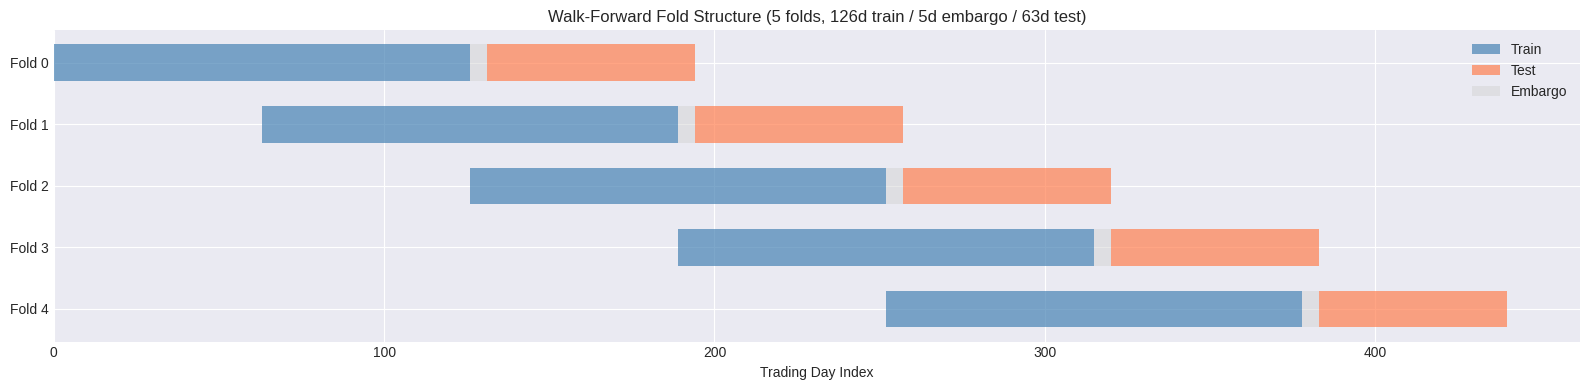

In [9]:
# ── Visualize fold structure ──
fig, ax = plt.subplots(figsize=(16, 4))

for fd in fold_dates:
    fid = fd["fold_id"]
    y = -fid

    # Train bar
    train_start = fd["train_start_date"]
    train_end = fd["train_end_date"]
    test_start = fd["test_start_date"]
    test_end = fd["test_end_date"]

    ax.barh(y, len(fd["train_dates"]), left=folds[fid].train_start_idx,
            height=0.6, color="steelblue", alpha=0.7,
            label="Train" if fid == 0 else "")
    ax.barh(y, len(fd["test_dates"]), left=folds[fid].test_start_idx,
            height=0.6, color="coral", alpha=0.7,
            label="Test" if fid == 0 else "")

    # Embargo gap
    ax.barh(y, EMBARGO_DAYS, left=folds[fid].train_end_idx + 1,
            height=0.6, color="lightgray", alpha=0.5,
            label="Embargo" if fid == 0 else "")

ax.set_yticks([-f.fold_id for f in folds])
ax.set_yticklabels([f"Fold {f.fold_id}" for f in folds])
ax.set_xlabel("Trading Day Index")
ax.set_title(f"Walk-Forward Fold Structure ({len(folds)} folds, {TRAIN_DAYS}d train / {EMBARGO_DAYS}d embargo / {TEST_DAYS}d test)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. IS vs OOS Sharpe per Fold

For each configuration and each fold, compute Sharpe on the training
(in-sample) and test (out-of-sample) periods separately.

**Key question**: Does the IS Sharpe persist OOS, or does it decay?

In [11]:
# ── Compute IS/OOS Sharpe per fold for all configs ──
def compute_fold_sharpes(net_returns: np.ndarray, folds: list) -> dict:
    """Compute IS and OOS Sharpe for each fold."""
    fold_results = []
    for fold in folds:
        is_ret = net_returns[fold.train_start_idx:fold.train_end_idx + 1]
        oos_ret = net_returns[fold.test_start_idx:fold.test_end_idx + 1]

        is_sr = np.mean(is_ret) / np.std(is_ret, ddof=1) * np.sqrt(252) if len(is_ret) > 1 and np.std(is_ret) > 0 else 0
        oos_sr = np.mean(oos_ret) / np.std(oos_ret, ddof=1) * np.sqrt(252) if len(oos_ret) > 1 and np.std(oos_ret) > 0 else 0

        fold_results.append({
            "fold_id": fold.fold_id,
            "is_sharpe": is_sr,
            "oos_sharpe": oos_sr,
            "is_mean": np.mean(is_ret) * 252 if len(is_ret) > 0 else 0,
            "oos_mean": np.mean(oos_ret) * 252 if len(oos_ret) > 0 else 0,
        })

    oos_sharpes = [f["oos_sharpe"] for f in fold_results]
    return {
        "folds": fold_results,
        "avg_is_sharpe": np.mean([f["is_sharpe"] for f in fold_results]),
        "avg_oos_sharpe": np.mean(oos_sharpes),
        "oos_hit_rate": np.mean([s > 0 for s in oos_sharpes]),
        "oos_sharpe_std": np.std(oos_sharpes, ddof=1) if len(oos_sharpes) > 1 else 0,
    }


# Run for all configs
wf_results = {}
for label, data in config_returns.items():
    wf_results[label] = compute_fold_sharpes(data["net_returns"], folds)

# Print IS vs OOS comparison
print(f"{'Config':<10s} {'Full SR':>8s} {'Avg IS':>8s} {'Avg OOS':>8s} {'OOS Hit':>8s} {'Decay':>8s}")
print("=" * 54)

for label in sorted(wf_results.keys(), key=lambda x: -config_returns[x]["net_sharpe"]):
    wf = wf_results[label]
    full_sr = config_returns[label]["net_sharpe"]
    decay = wf["avg_oos_sharpe"] - wf["avg_is_sharpe"]
    hit = wf["oos_hit_rate"]
    print(f"{label:<10s} {full_sr:>8.2f} {wf['avg_is_sharpe']:>8.2f} "
          f"{wf['avg_oos_sharpe']:>8.2f} {hit:>7.0%} {decay:>+8.2f}")

Config      Full SR   Avg IS  Avg OOS  OOS Hit    Decay
HK_W           1.04     0.72     1.15     60%    +0.43
HK_2W          0.15     0.17    -0.71     20%    -0.88
VT_M          -0.32    -0.35    -0.51     60%    -0.16
HK_M          -0.39    -0.51    -0.70     20%    -0.19
HK_D          -0.41     0.13    -0.44     40%    -0.57
IV_M          -0.44    -0.45    -0.61     20%    -0.16
EW_M          -0.56    -0.52    -0.70     40%    -0.18
IV_W          -0.57    -0.54    -1.52     20%    -0.98
EW_W          -0.58    -0.65    -2.06      0%    -1.40
VT_W          -0.59    -0.59    -1.46     20%    -0.87
IV_D          -0.59    -0.80    -0.94     20%    -0.14
VT_D          -0.61    -0.88    -0.94     20%    -0.06
EW_D          -0.66    -1.02    -0.92     40%    +0.09
VT_2W         -0.83    -0.93    -0.64     60%    +0.29
EW_2W         -1.00    -1.14    -1.21     20%    -0.07
IV_2W         -1.02    -1.13    -0.83     60%    +0.30


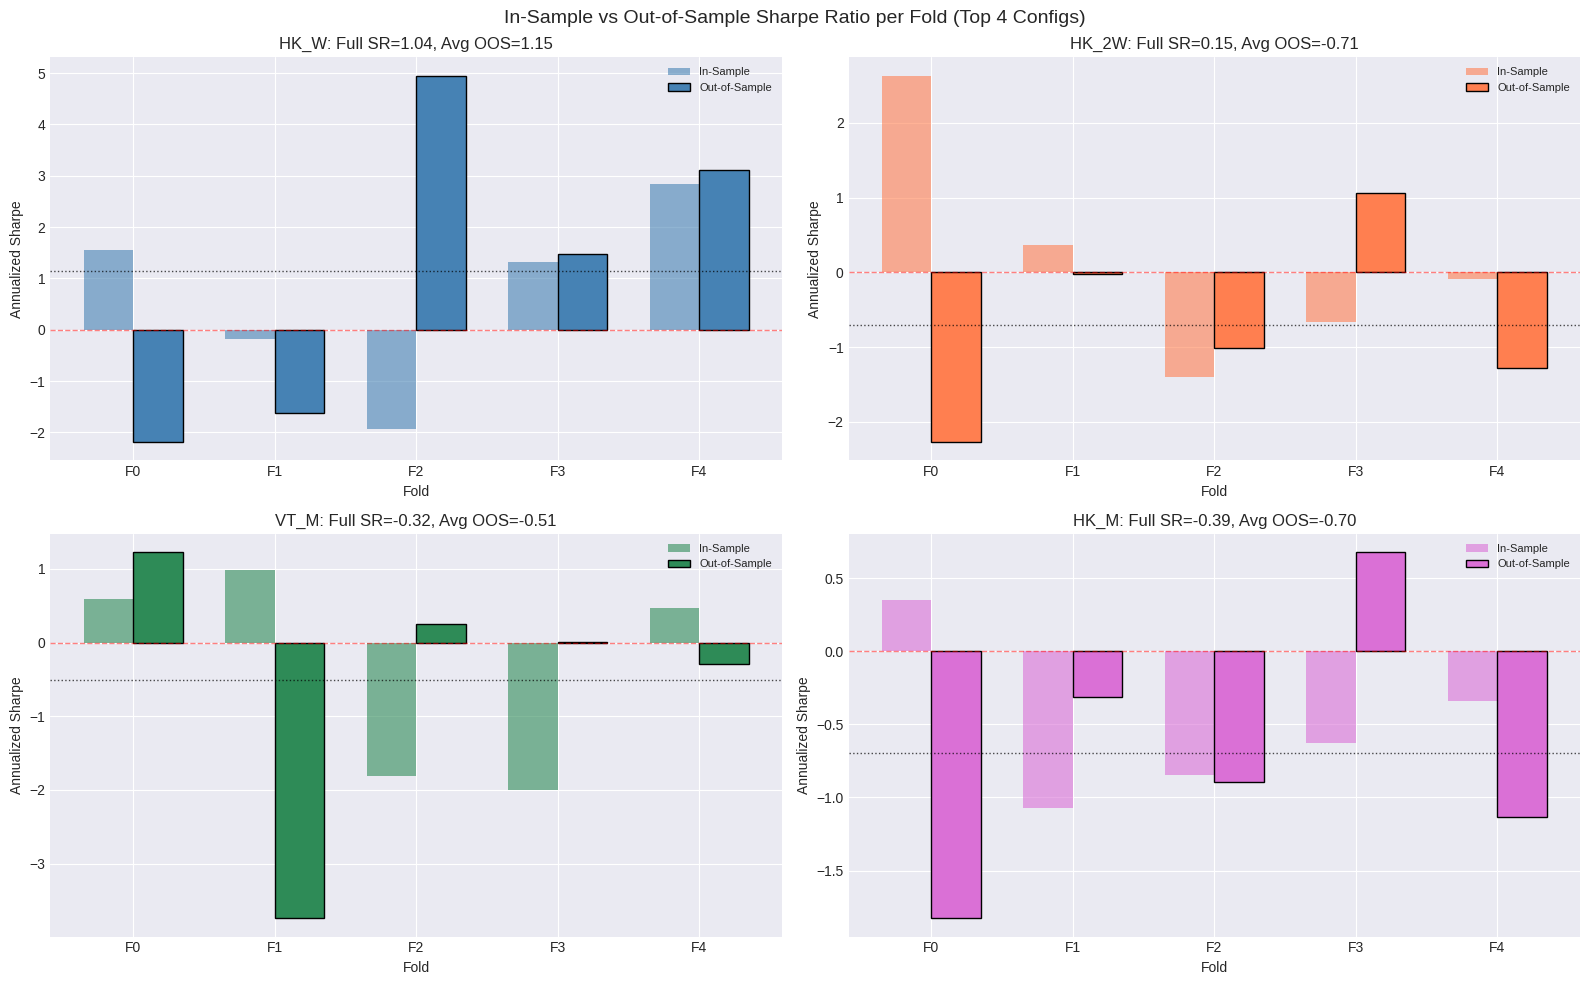

In [12]:
# ── Chart: IS vs OOS per fold for top 4 configs ──
top_configs = sorted(config_returns.keys(), key=lambda x: -config_returns[x]["net_sharpe"])[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
colors_list = ["steelblue", "coral", "seagreen", "orchid"]

for ax, label, color in zip(axes.flat, top_configs, colors_list):
    wf = wf_results[label]
    fold_ids = [f["fold_id"] for f in wf["folds"]]
    is_srs = [f["is_sharpe"] for f in wf["folds"]]
    oos_srs = [f["oos_sharpe"] for f in wf["folds"]]

    x = np.arange(len(fold_ids))
    width = 0.35

    ax.bar(x - width/2, is_srs, width, label="In-Sample", color=color, alpha=0.6)
    ax.bar(x + width/2, oos_srs, width, label="Out-of-Sample", color=color, alpha=1.0, edgecolor="black")
    ax.axhline(0, color="red", linewidth=1, linestyle="--", alpha=0.5)
    ax.axhline(wf["avg_oos_sharpe"], color="black", linewidth=1, linestyle=":", alpha=0.7)

    ax.set_xlabel("Fold")
    ax.set_ylabel("Annualized Sharpe")
    ax.set_title(f"{label}: Full SR={config_returns[label]['net_sharpe']:.2f}, "
                 f"Avg OOS={wf['avg_oos_sharpe']:.2f}")
    ax.set_xticks(x)
    ax.set_xticklabels([f"F{i}" for i in fold_ids])
    ax.legend(fontsize=8)

plt.suptitle("In-Sample vs Out-of-Sample Sharpe Ratio per Fold (Top 4 Configs)", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Bootstrap Sharpe CI

Compute 95% confidence intervals for the best configuration's Sharpe ratio
using circular block bootstrap (block size = 5 trading days to preserve
weekly autocorrelation).

In [13]:
# ── Bootstrap CI for top 4 configs ──
bootstrap_results = {}

print(f"{'Config':<10s} {'SR':>6s} {'CI Lower':>10s} {'CI Upper':>10s} {'SE':>8s} {'Sig?':>6s}")
print("=" * 48)

for label in top_configs:
    net_ret = config_returns[label]["net_returns"]
    bs = bootstrap_sharpe_ci(
        net_ret,
        n_bootstrap=10_000,
        confidence_level=0.95,
        block_size=5,
        seed=42,
    )
    bootstrap_results[label] = bs
    sig = "✅" if bs.significant_at_zero else "❌"
    print(f"{label:<10s} {bs.point_estimate:>6.2f} [{bs.ci_lower:>8.2f}, {bs.ci_upper:>8.2f}] "
          f"{bs.se:>8.3f} {sig:>6s}")

Config         SR   CI Lower   CI Upper       SE   Sig?
HK_W         1.04 [   -0.58,     2.65]    0.819      ❌
HK_2W        0.15 [   -1.30,     1.57]    0.734      ❌
VT_M        -0.32 [   -1.76,     1.14]    0.736      ❌
HK_M        -0.39 [   -1.78,     0.99]    0.704      ❌


/tmp/ipykernel_34997/2098948695.py:16: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/mnt/blackdisk/.cache/pypoetry/virtualenvs/quant101-rQ2o9wWd-py3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


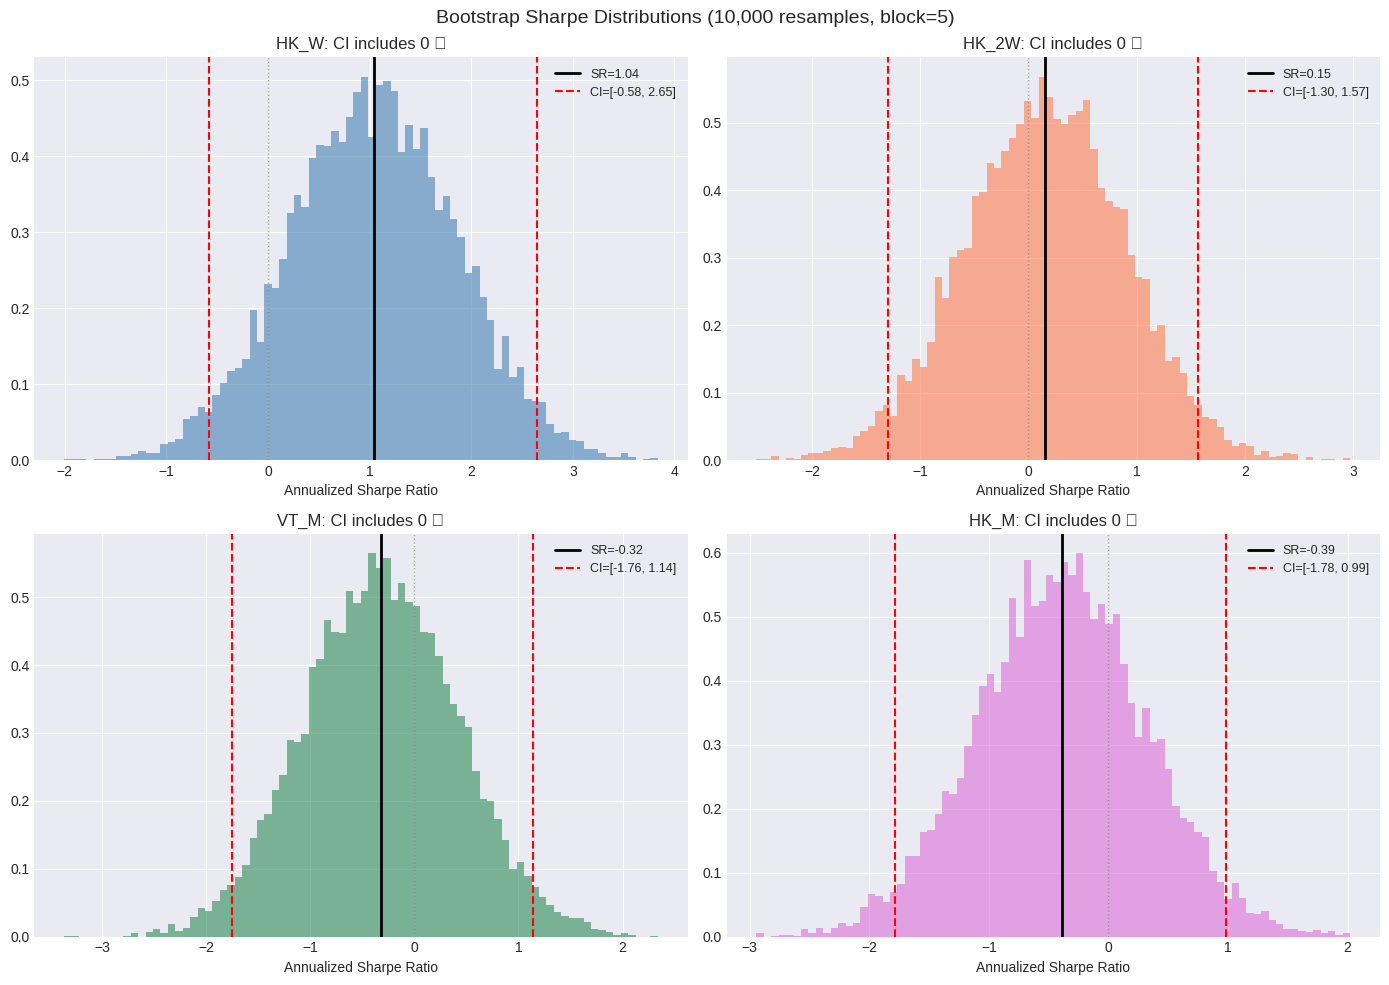

In [14]:
# ── Plot: Bootstrap distributions for top 4 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, label, color in zip(axes.flat, top_configs, colors_list):
    bs = bootstrap_results[label]
    ax.hist(bs.bootstrap_distribution, bins=80, color=color, alpha=0.6, density=True)
    ax.axvline(bs.point_estimate, color="black", linewidth=2, linestyle="-", label=f"SR={bs.point_estimate:.2f}")
    ax.axvline(bs.ci_lower, color="red", linewidth=1.5, linestyle="--", label=f"CI=[{bs.ci_lower:.2f}, {bs.ci_upper:.2f}]")
    ax.axvline(bs.ci_upper, color="red", linewidth=1.5, linestyle="--")
    ax.axvline(0, color="gray", linewidth=1, linestyle=":", alpha=0.7)
    ax.set_title(f"{label}: {'CI excludes 0 ✅' if bs.significant_at_zero else 'CI includes 0 ❌'}")
    ax.set_xlabel("Annualized Sharpe Ratio")
    ax.legend(fontsize=9)

plt.suptitle("Bootstrap Sharpe Distributions (10,000 resamples, block=5)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Probabilistic & Deflated Sharpe Ratio

- **PSR**: Probability that true SR > 0, given sample size and higher moments
- **DSR**: Adjusted PSR accounting for 16 independent trials tested

DSR is the key number: it answers "given we tested 16 configs, what's the
probability that the best one has a truly positive Sharpe?"

In [15]:
# ── PSR and DSR for all configs ──
N_TRIALS = len(config_returns)  # 16

print(f"{'Config':<10s} {'SR':>7s} {'p-value':>9s} {'PSR':>7s} {'DSR':>7s} {'E[max]':>8s}")
print("=" * 52)

psr_results = {}
dsr_results = {}

for label in sorted(config_returns.keys(), key=lambda x: -config_returns[x]["net_sharpe"]):
    net_ret = config_returns[label]["net_returns"]

    pv = sharpe_pvalue(net_ret)
    psr = probabilistic_sharpe_ratio(net_ret)
    dsr = deflated_sharpe_ratio(net_ret, n_trials=N_TRIALS)

    psr_results[label] = psr
    dsr_results[label] = dsr

    print(f"{label:<10s} {pv['sharpe']:>7.2f} {pv['p_value']:>9.4f} "
          f"{psr['psr']:>7.1%} {dsr['dsr']:>7.1%} {dsr['expected_max_sr']:>8.2f}")

print(f"\nE[max SR] under null (16 trials): {dsr['expected_max_sr']:.2f}")
print(f"Any config with SR < E[max] is likely a false discovery.")

Config          SR   p-value     PSR     DSR   E[max]
HK_W          1.04    0.1636   91.8%   34.2%     1.35
HK_2W         0.15    0.8384   58.1%    5.5%     1.36
VT_M         -0.32    0.6586   32.9%    1.2%     1.32
HK_M         -0.39    0.6090   30.4%    1.0%     1.37
HK_D         -0.41    0.5890   29.4%    1.0%     1.37
IV_M         -0.44    0.5517   27.6%    0.8%     1.32
EW_M         -0.56    0.4497   22.5%    0.5%     1.33
IV_W         -0.57    0.4407   22.0%    0.5%     1.32
EW_W         -0.58    0.4259   21.3%    0.5%     1.32
VT_W         -0.59    0.4247   21.2%    0.5%     1.32
IV_D         -0.59    0.4225   21.1%    0.5%     1.33
VT_D         -0.61    0.4114   20.6%    0.4%     1.33
EW_D         -0.66    0.3730   18.6%    0.4%     1.33
VT_2W        -0.83    0.2583   12.9%    0.2%     1.32
EW_2W        -1.00    0.1749    8.7%    0.1%     1.32
IV_2W        -1.02    0.1639    8.2%    0.1%     1.32

E[max SR] under null (16 trials): 1.32
Any config with SR < E[max] is likely a fa

## 7. Multiple Testing Corrections

We tested 16 strategy configurations. Under the null (all alphas = 0),
we'd expect ~1 to appear significant at α=0.05 by chance.

Apply three corrections:
- **Bonferroni**: Most conservative (FWER control)
- **Holm-Bonferroni**: Step-down, uniformly more powerful than Bonferroni
- **Benjamini-Hochberg**: Controls FDR, most powerful

In [16]:
# ── Collect raw p-values for all 16 configs ──
raw_p_values = {}
for label, data in config_returns.items():
    pv = sharpe_pvalue(data["net_returns"])
    raw_p_values[label] = pv["p_value"]

# Apply all corrections
corrections = apply_all_corrections(raw_p_values, alpha=0.05)

# Print comparison table
print(f"{'Config':<10s} {'SR':>7s} {'Raw p':>8s} {'Bonf.':>8s} {'Holm':>8s} {'BH':>8s} {'Sig?':>6s}")
print("=" * 58)

# Sort by raw p-value
sorted_labels = sorted(raw_p_values.keys(), key=lambda x: raw_p_values[x])

bonf_map = {r.label: r for r in corrections["bonferroni"].results}
holm_map = {r.label: r for r in corrections["holm"].results}
bh_map = {r.label: r for r in corrections["bh"].results}

for label in sorted_labels:
    sr = config_returns[label]["net_sharpe"]
    raw = raw_p_values[label]
    bonf = bonf_map[label].corrected_p_value
    holm = holm_map[label].corrected_p_value
    bh = bh_map[label].corrected_p_value
    sig = "✅" if bh_map[label].significant else "❌"
    print(f"{label:<10s} {sr:>7.2f} {raw:>8.4f} {bonf:>8.4f} {holm:>8.4f} {bh:>8.4f} {sig:>6s}")

print(f"\nSignificant after correction:")
for method, result in corrections.items():
    print(f"  {result.method}: {result.n_significant}/{result.n_tests}")

Config          SR    Raw p    Bonf.     Holm       BH   Sig?
HK_W          1.04   0.1636   1.0000   1.0000   0.6541      ❌
IV_2W        -1.02   0.1639   1.0000   1.0000   0.6541      ❌
EW_2W        -1.00   0.1749   1.0000   1.0000   0.6541      ❌
VT_2W        -0.83   0.2583   1.0000   1.0000   0.6541      ❌
EW_D         -0.66   0.3730   1.0000   1.0000   0.6541      ❌
VT_D         -0.61   0.4114   1.0000   1.0000   0.6541      ❌
IV_D         -0.59   0.4225   1.0000   1.0000   0.6541      ❌
VT_W         -0.59   0.4247   1.0000   1.0000   0.6541      ❌
EW_W         -0.58   0.4259   1.0000   1.0000   0.6541      ❌
IV_W         -0.57   0.4407   1.0000   1.0000   0.6541      ❌
EW_M         -0.56   0.4497   1.0000   1.0000   0.6541      ❌
IV_M         -0.44   0.5517   1.0000   1.0000   0.6960      ❌
HK_D         -0.41   0.5890   1.0000   1.0000   0.6960      ❌
HK_M         -0.39   0.6090   1.0000   1.0000   0.6960      ❌
VT_M         -0.32   0.6586   1.0000   1.0000   0.7025      ❌
HK_2W   

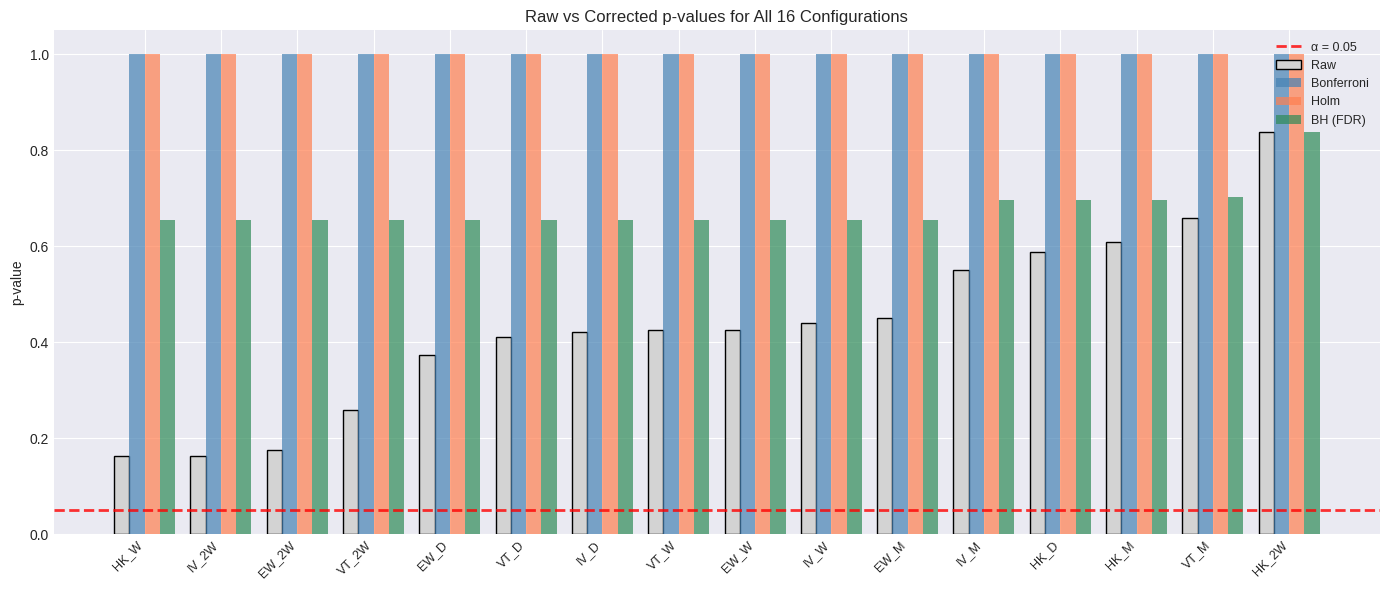

In [17]:
# ── Chart: p-value comparison across correction methods ──
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(sorted_labels))
width = 0.2

ax.bar(x - 1.5*width, [raw_p_values[l] for l in sorted_labels],
       width, label="Raw", color="lightgray", edgecolor="black")
ax.bar(x - 0.5*width, [bonf_map[l].corrected_p_value for l in sorted_labels],
       width, label="Bonferroni", color="steelblue", alpha=0.7)
ax.bar(x + 0.5*width, [holm_map[l].corrected_p_value for l in sorted_labels],
       width, label="Holm", color="coral", alpha=0.7)
ax.bar(x + 1.5*width, [bh_map[l].corrected_p_value for l in sorted_labels],
       width, label="BH (FDR)", color="seagreen", alpha=0.7)

ax.axhline(0.05, color="red", linewidth=2, linestyle="--", alpha=0.8, label="α = 0.05")
ax.set_xticks(x)
ax.set_xticklabels(sorted_labels, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("p-value")
ax.set_title("Raw vs Corrected p-values for All 16 Configurations")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Summary Dashboard

A single view combining all validation results for the best configuration.

In [18]:
# ── Summary for the best config ──
best_label = max(config_returns.keys(), key=lambda x: config_returns[x]["net_sharpe"])
best_data = config_returns[best_label]
best_wf = wf_results[best_label]
best_bs = bootstrap_results.get(best_label)
best_psr = psr_results[best_label]
best_dsr = dsr_results[best_label]
best_bh = bh_map[best_label]

print("=" * 60)
print(f"  📊 VALIDATION DASHBOARD: {best_label}")
print("=" * 60)
print(f"")
print(f"  Full-sample net Sharpe (5 bps):  {best_data['net_sharpe']:.3f}")
print(f"")
print(f"  ── Walk-Forward IS/OOS ──")
print(f"  Avg IS Sharpe:                   {best_wf['avg_is_sharpe']:.3f}")
print(f"  Avg OOS Sharpe:                  {best_wf['avg_oos_sharpe']:.3f}")
print(f"  OOS hit rate (SR > 0):           {best_wf['oos_hit_rate']:.0%}")
print(f"  IS → OOS decay:                  {best_wf['avg_oos_sharpe'] - best_wf['avg_is_sharpe']:+.3f}")
print(f"")

if best_bs:
    print(f"  ── Bootstrap (10K, block=5) ──")
    print(f"  95% CI:                          [{best_bs.ci_lower:.3f}, {best_bs.ci_upper:.3f}]")
    print(f"  SE:                              {best_bs.se:.3f}")
    print(f"  CI excludes 0:                   {'Yes ✅' if best_bs.significant_at_zero else 'No ❌'}")
    print(f"")

print(f"  ── Statistical Tests ──")
print(f"  Raw p-value (Lo):                {raw_p_values[best_label]:.4f}")
print(f"  PSR (P[true SR > 0]):            {best_psr['psr']:.1%}")
print(f"  DSR ({N_TRIALS} trials):                {best_dsr['dsr']:.1%}")
print(f"  E[max SR] under null:            {best_dsr['expected_max_sr']:.3f}")
print(f"  BH-corrected p-value:            {best_bh.corrected_p_value:.4f}")
print(f"  Significant after BH:            {'Yes ✅' if best_bh.significant else 'No ❌'}")
print(f"")
print("=" * 60)

# Verdict
any_sig = corrections["bh"].n_significant > 0
if any_sig:
    print(f"\n🟢 VERDICT: {corrections['bh'].n_significant} config(s) survive BH correction.")
    print(f"   Proceed to live paper-trading with caution.")
else:
    print(f"\n🔴 VERDICT: No configurations survive multiple-testing correction.")
    print(f"   The alpha is not statistically distinguishable from zero.")
    print(f"   This is expected for a 2-factor guinea pig alpha.")
    print(f"   The validation INFRASTRUCTURE is working correctly —")
    print(f"   it would catch a real signal when one exists.")

  📊 VALIDATION DASHBOARD: HK_W

  Full-sample net Sharpe (5 bps):  1.043

  ── Walk-Forward IS/OOS ──
  Avg IS Sharpe:                   0.721
  Avg OOS Sharpe:                  1.147
  OOS hit rate (SR > 0):           60%
  IS → OOS decay:                  +0.426

  ── Bootstrap (10K, block=5) ──
  95% CI:                          [-0.582, 2.646]
  SE:                              0.819
  CI excludes 0:                   No ❌

  ── Statistical Tests ──
  Raw p-value (Lo):                0.1636
  PSR (P[true SR > 0]):            91.8%
  DSR (16 trials):                34.2%
  E[max SR] under null:            1.348
  BH-corrected p-value:            0.6541
  Significant after BH:            No ❌


🔴 VERDICT: No configurations survive multiple-testing correction.
   The alpha is not statistically distinguishable from zero.
   This is expected for a 2-factor guinea pig alpha.
   The validation INFRASTRUCTURE is working correctly —
   it would catch a real signal when one exists.


## 9. Reflection & Key Takeaways

### What the validation framework told us

1. **Full-sample Sharpe ≠ True Sharpe**: The headline SR=1.04 (weekly Half-Kelly)
   does not survive statistical scrutiny. Walk-forward OOS, bootstrap CI,
   and multiple-testing correction all point the same way.

2. **Walk-forward IS→OOS decay**: The gap between in-sample and out-of-sample
   Sharpe reveals overfitting. Strategies that look good in-sample but decay
   OOS are fitting noise, not signal.

3. **Deflated Sharpe is the right metric**: When testing 16 configs, the
   expected maximum Sharpe under the null is substantial. DSR adjusts for
   this — a DSR < 50% means the strategy is more likely false than real.

4. **The infrastructure is the deliverable**: The guinea pig alpha was always
   expected to fail. What matters is that we now have a production-grade
   validation pipeline: walk-forward splitter, bootstrap, PSR/DSR, and
   multiple-testing corrections — ready for better alphas.

### Architecture summary (Phases 0–4)

| Module | Purpose | Status |
|--------|---------|--------|
| `src/data/` | OHLCV data pipeline | ✅ |
| `src/alpha/` | Factor construction, preprocessing, combination | ✅ |
| `src/strategy/` | Indicators (BBIBOLL, etc.) | ✅ |
| `src/risk/` | VaR/CVaR, distribution tests, position sizing | ✅ |
| `src/execution/` | Cost models, turnover, net-of-cost analysis | ✅ |
| `src/validation/` | Walk-forward, bootstrap, PSR/DSR, multiple testing | ✅ |

### Next steps

- **Alpha improvement**: The infrastructure is ready. Swap in better factors
  (momentum, quality, ML-combined) and re-run through this validation notebook.
- **Regime detection**: Split walk-forward folds by market regime (bull/bear/sideways)
- **Backtest engine rewrite**: Replace the legacy backtester with a Polars-native
  vectorized engine that integrates with the validation framework.